<a href="https://colab.research.google.com/github/anp2/Declarative-Pipeline/blob/master/CO2_Emission.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

In [2]:
from google.colab import files

uploaded = files.upload()

Saving CO2_Emissions.csv to CO2_Emissions.csv


In [13]:
df = pd.read_csv("CO2_Emissions.csv")

**Q1 and Q2**

In [5]:
print("Number of Rows :", df.shape[0])
print("Number of Columns :", df.shape[1])
df.columns
df.info()

Number of Rows : 7385
Number of Columns : 12
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7385 entries, 0 to 7384
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Make                              7385 non-null   object 
 1   Model                             7385 non-null   object 
 2   Vehicle Class                     7385 non-null   object 
 3   Engine Size(L)                    7385 non-null   float64
 4   Cylinders                         7385 non-null   int64  
 5   Transmission                      7385 non-null   object 
 6   Fuel Type                         7385 non-null   object 
 7   Fuel Consumption City (L/100 km)  7385 non-null   float64
 8   Fuel Consumption Hwy (L/100 km)   7385 non-null   float64
 9   Fuel Consumption Comb (L/100 km)  7385 non-null   float64
 10  Fuel Consumption Comb (mpg)       7385 non-null   int64  
 11  CO2 Emissions(g/km)     

In [6]:
df.describe(include='all')

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
count,7385,7385,7385,7385.000000,7385.000000,7385,7385,7385.000000,7385.000000,7385.000000,7385.000000,7385.000000
unique,42,2053,16,NaN,NaN,27,5,NaN,NaN,NaN,NaN,NaN
top,FORD,F-150 FFV,SUV - SMALL,NaN,NaN,AS6,X,NaN,NaN,NaN,NaN,NaN
freq,628,32,1217,NaN,NaN,1324,3637,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,3.160068,5.615030,NaN,NaN,12.556534,9.041706,10.975071,27.481652,250.584699
std,NaN,NaN,NaN,1.354170,1.828307,NaN,NaN,3.500274,2.224456,2.892506,7.231879,58.512679
min,NaN,NaN,NaN,0.900000,3.000000,NaN,NaN,4.200000,4.000000,4.100000,11.000000,96.000000
25%,NaN,NaN,NaN,2.000000,4.000000,NaN,NaN,10.100000,7.500000,8.900000,22.000000,208.000000
50%,NaN,NaN,NaN,3.000000,6.000000,NaN,NaN,12.100000,8.700000,10.600000,27.000000,246.000000
75%,NaN,NaN,NaN,3.700000,6.000000,NaN,NaN,14.600000,10.200000,12.600000,32.000000,288.000000


In [7]:
df.isnull().sum()

,0
Make,0
Model,0
Vehicle Class,0
Engine Size(L),0
Cylinders,0
Transmission,0
Fuel Type,0
Fuel Consumption City (L/100 km),0
Fuel Consumption Hwy (L/100 km),0
Fuel Consumption Comb (L/100 km),0


In [8]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 1103


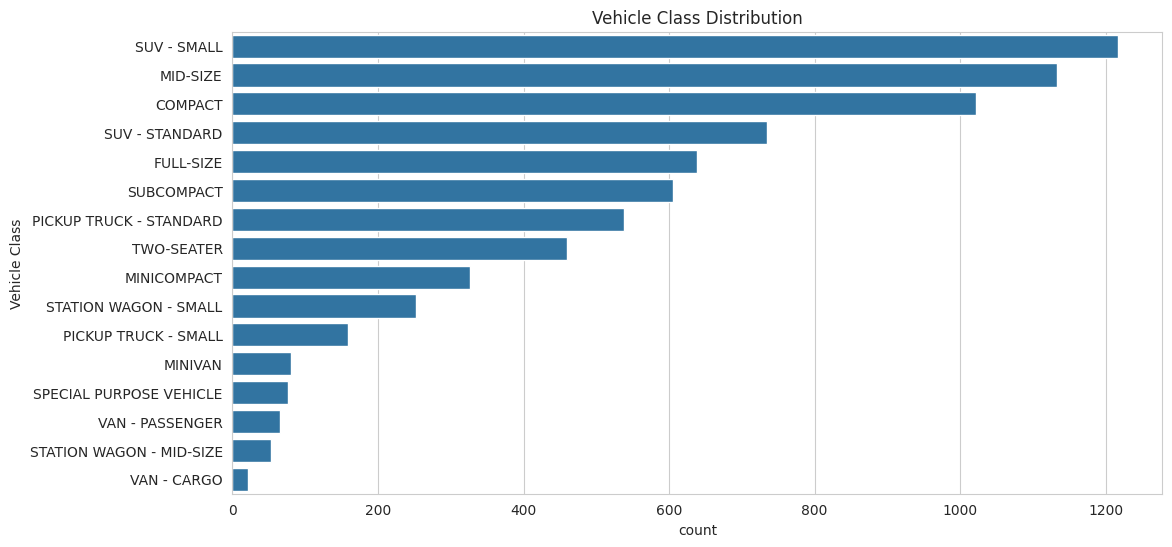

In [9]:
plt.figure(figsize=(12,6))

sns.countplot(data=df,
              y="Vehicle Class",
              order=df["Vehicle Class"].value_counts().index)

plt.title("Vehicle Class Distribution")

plt.show()

In [11]:
categorical_cols = df.select_dtypes(include='object').columns

numerical_cols = df.select_dtypes(exclude='object').columns

print("Categorical Features")
print(categorical_cols)

print()

print("Numerical Features")
print(numerical_cols)

Categorical Features
Index(['Make', 'Model', 'Vehicle Class', 'Transmission', 'Fuel Type'], dtype='object')

Numerical Features
Index(['Engine Size(L)', 'Cylinders', 'Fuel Consumption City (L/100 km)',
       'Fuel Consumption Hwy (L/100 km)', 'Fuel Consumption Comb (L/100 km)',
       'Fuel Consumption Comb (mpg)', 'CO2 Emissions(g/km)'],
      dtype='object')


In [12]:
print("Dataset Summary")
print("-"*50)

print(f"Total Vehicles : {df.shape[0]}")
print(f"Total Features : {df.shape[1]-1}")
print(f"Target Variable : CO2 Emissions(g/km)")

print("\nCategorical Features")
print(list(categorical_cols))

print("\nNumerical Features")
print(list(numerical_cols))

Dataset Summary
--------------------------------------------------
Total Vehicles : 7385
Total Features : 11
Target Variable : CO2 Emissions(g/km)

Categorical Features
['Make', 'Model', 'Vehicle Class', 'Transmission', 'Fuel Type']

Numerical Features
['Engine Size(L)', 'Cylinders', 'Fuel Consumption City (L/100 km)', 'Fuel Consumption Hwy (L/100 km)', 'Fuel Consumption Comb (L/100 km)', 'Fuel Consumption Comb (mpg)', 'CO2 Emissions(g/km)']


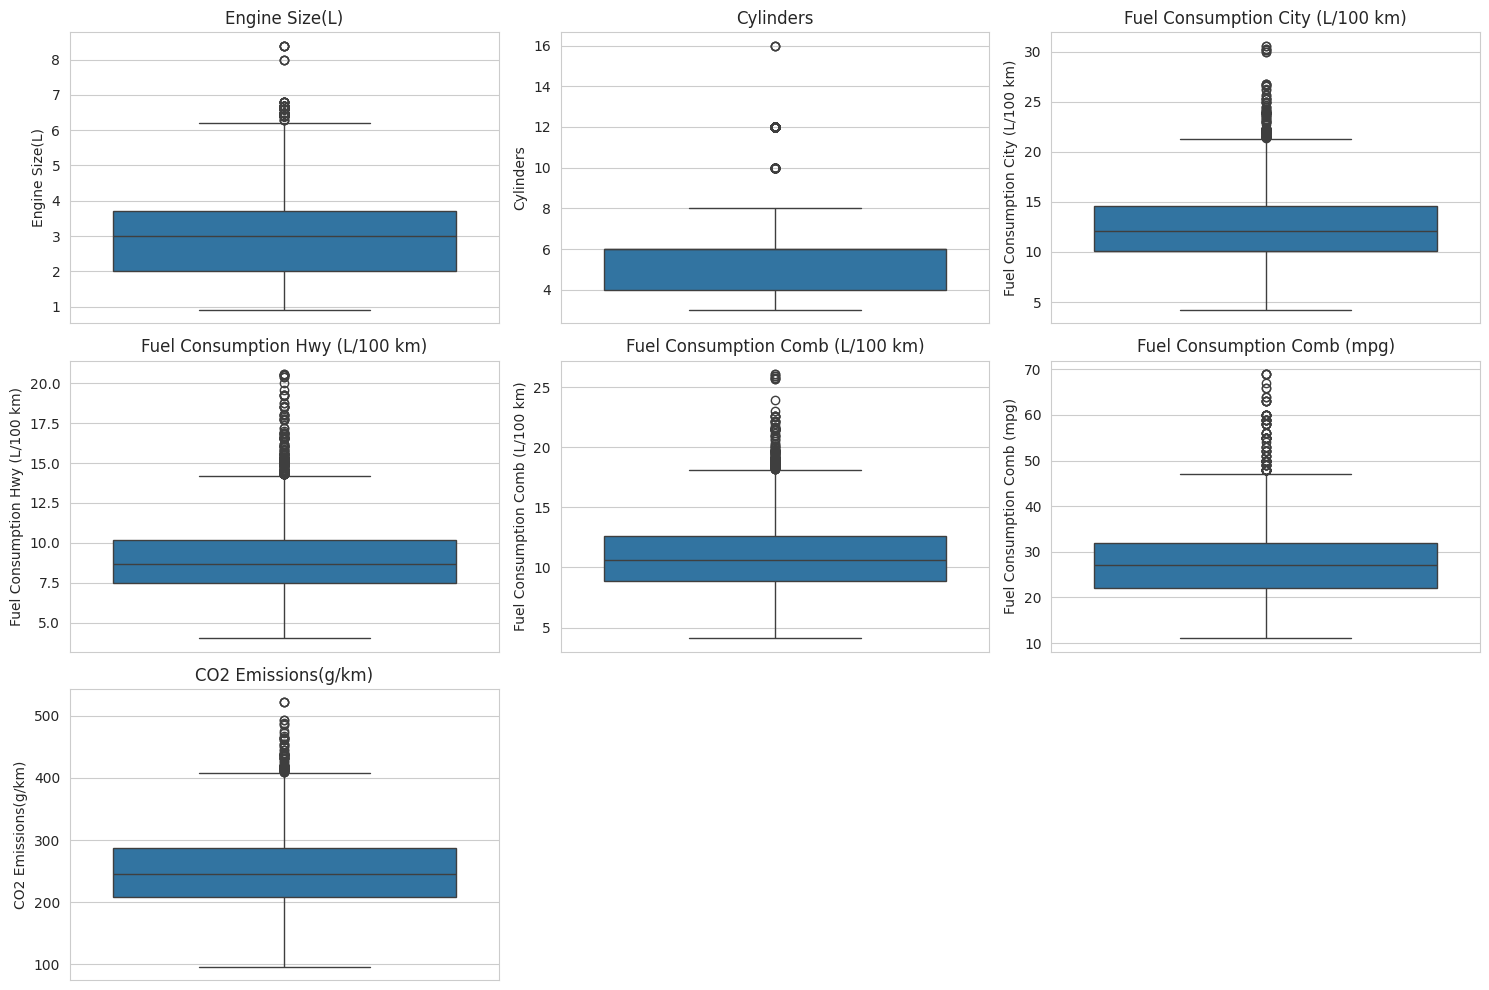

In [14]:
numeric_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15,10))

for i,col in enumerate(numeric_cols):

    plt.subplot(3,3,i+1)

    sns.boxplot(y=df[col])

    plt.title(col)

plt.tight_layout()

plt.show()

In [15]:
print("="*60)
print("DATA QUALITY REPORT")
print("="*60)

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nMissing Values")
print(df.isnull().sum())

print("\nDuplicate Rows")
print(df.duplicated().sum())

print("\nData Types")
print(df.dtypes)

print("\nNumerical Summary")
print(df.describe().T)

DATA QUALITY REPORT
Rows: 7385
Columns: 12

Missing Values
Make                                0
Model                               0
Vehicle Class                       0
Engine Size(L)                      0
Cylinders                           0
Transmission                        0
Fuel Type                           0
Fuel Consumption City (L/100 km)    0
Fuel Consumption Hwy (L/100 km)     0
Fuel Consumption Comb (L/100 km)    0
Fuel Consumption Comb (mpg)         0
CO2 Emissions(g/km)                 0
dtype: int64

Duplicate Rows
1103

Data Types
Make                                 object
Model                                object
Vehicle Class                        object
Engine Size(L)                      float64
Cylinders                             int64
Transmission                         object
Fuel Type                            object
Fuel Consumption City (L/100 km)    float64
Fuel Consumption Hwy (L/100 km)     float64
Fuel Consumption Comb (L/100 km)    float64

**Q3 & Q4**

Correlation Matrix

In [17]:
numeric_df = df.select_dtypes(include=np.number)

corr_matrix = numeric_df.corr()

corr_matrix

,Engine Size(L),Cylinders,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
Engine Size(L),1.000000,0.927653,0.831379,0.761526,0.817060,-0.757854,0.851145
Cylinders,0.927653,1.000000,0.800702,0.715252,0.780534,-0.719321,0.832644
Fuel Consumption City (L/100 km),0.831379,0.800702,1.000000,0.948180,0.993810,-0.927059,0.919592
Fuel Consumption Hwy (L/100 km),0.761526,0.715252,0.948180,1.000000,0.977299,-0.890638,0.883536
Fuel Consumption Comb (L/100 km),0.817060,0.780534,0.993810,0.977299,1.000000,-0.925576,0.918052
Fuel Consumption Comb (mpg),-0.757854,-0.719321,-0.927059,-0.890638,-0.925576,1.000000,-0.907426
CO2 Emissions(g/km),0.851145,0.832644,0.919592,0.883536,0.918052,-0.907426,1.000000


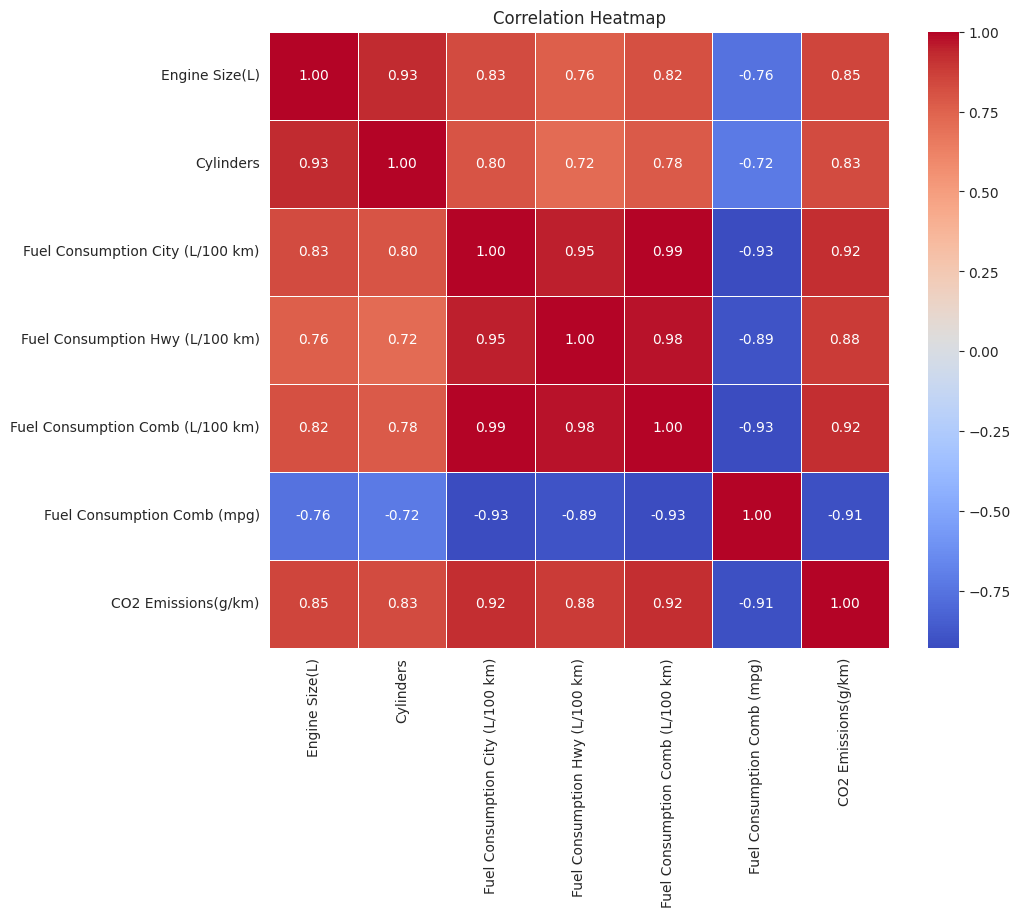

In [18]:
# Correlation Heatmap

plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.show()

In [19]:
# Correlation with Target Variable
corr_target = corr_matrix["CO2 Emissions(g/km)"]\
                .sort_values(ascending=False)

print(corr_target)

CO2 Emissions(g/km)                 1.000000
Fuel Consumption City (L/100 km)    0.919592
Fuel Consumption Comb (L/100 km)    0.918052
Fuel Consumption Hwy (L/100 km)     0.883536
Engine Size(L)                      0.851145
Cylinders                           0.832644
Fuel Consumption Comb (mpg)        -0.907426
Name: CO2 Emissions(g/km), dtype: float64


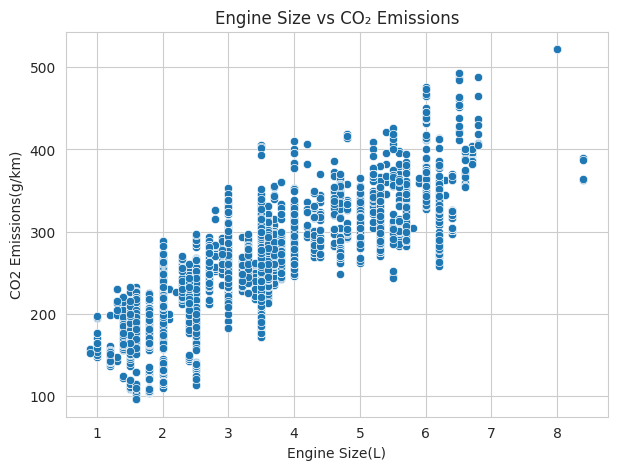

In [20]:
# Scatter Plot - Engine Size vs CO₂
plt.figure(figsize=(7,5))

sns.scatterplot(
    data=df,
    x="Engine Size(L)",
    y="CO2 Emissions(g/km)"
)

plt.title("Engine Size vs CO₂ Emissions")

plt.show()

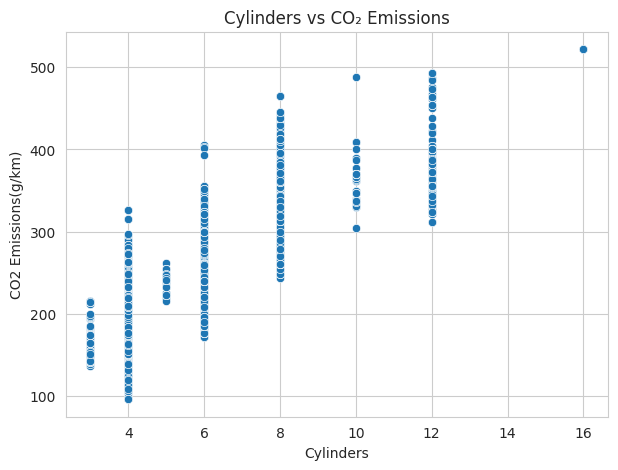

In [21]:
# Scatter Plot - Cylinders

plt.figure(figsize=(7,5))

sns.scatterplot(
    data=df,
    x="Cylinders",
    y="CO2 Emissions(g/km)"
)

plt.title("Cylinders vs CO₂ Emissions")

plt.show()

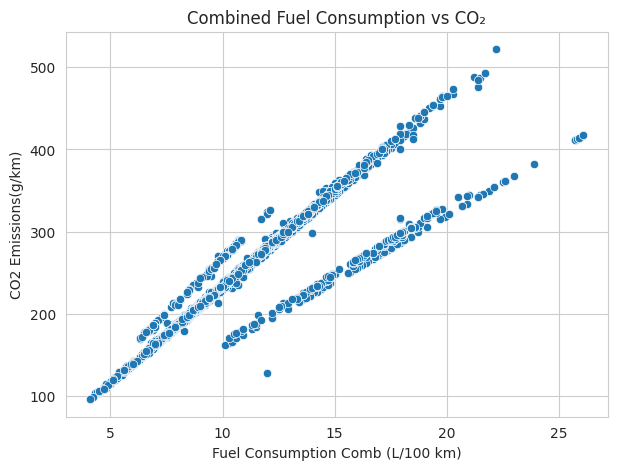

In [22]:
# Fuel Consumption vs CO₂

plt.figure(figsize=(7,5))

sns.scatterplot(
    data=df,
    x="Fuel Consumption Comb (L/100 km)",
    y="CO2 Emissions(g/km)"
)

plt.title("Combined Fuel Consumption vs CO₂")

plt.show()

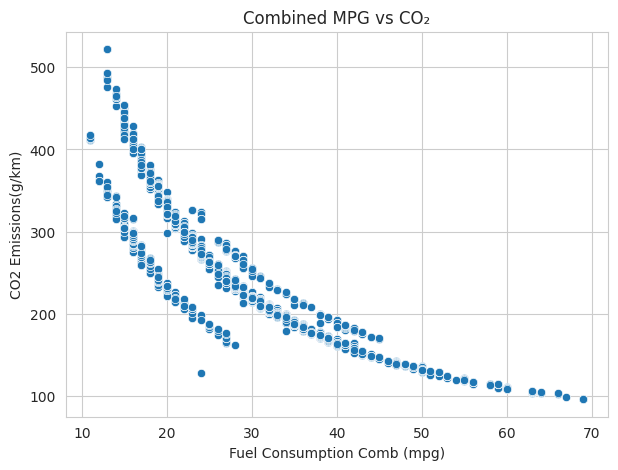

In [23]:
# MPG vs CO₂
plt.figure(figsize=(7,5))

sns.scatterplot(
    data=df,
    x="Fuel Consumption Comb (mpg)",
    y="CO2 Emissions(g/km)"
)

plt.title("Combined MPG vs CO₂")

plt.show()

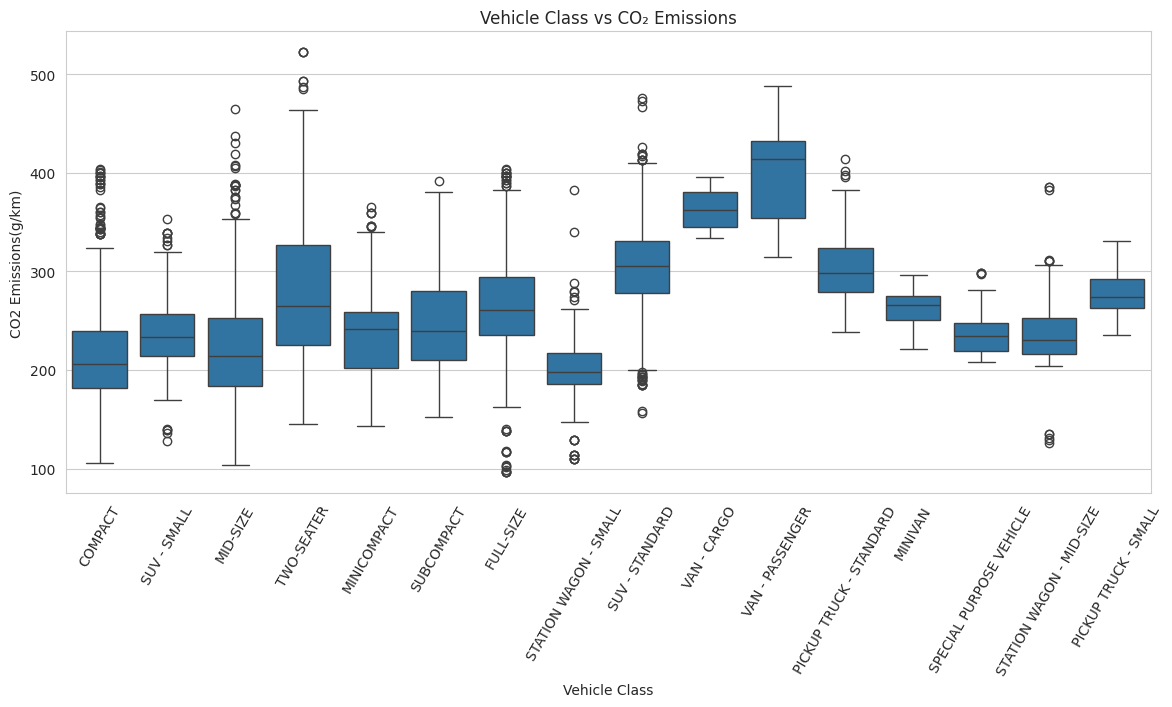

In [24]:
# Vehicle Class vs CO₂

plt.figure(figsize=(14,6))

sns.boxplot(
    data=df,
    x="Vehicle Class",
    y="CO2 Emissions(g/km)"
)

plt.xticks(rotation=60)

plt.title("Vehicle Class vs CO₂ Emissions")

plt.show()

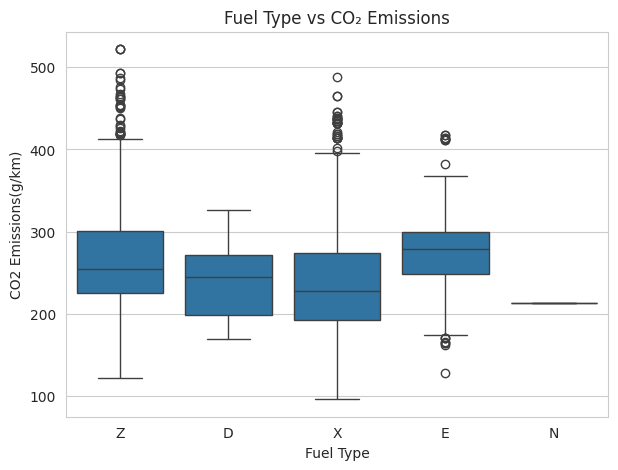

In [25]:
# Fuel Type vs CO₂

plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x="Fuel Type",
    y="CO2 Emissions(g/km)"
)

plt.title("Fuel Type vs CO₂ Emissions")

plt.show()

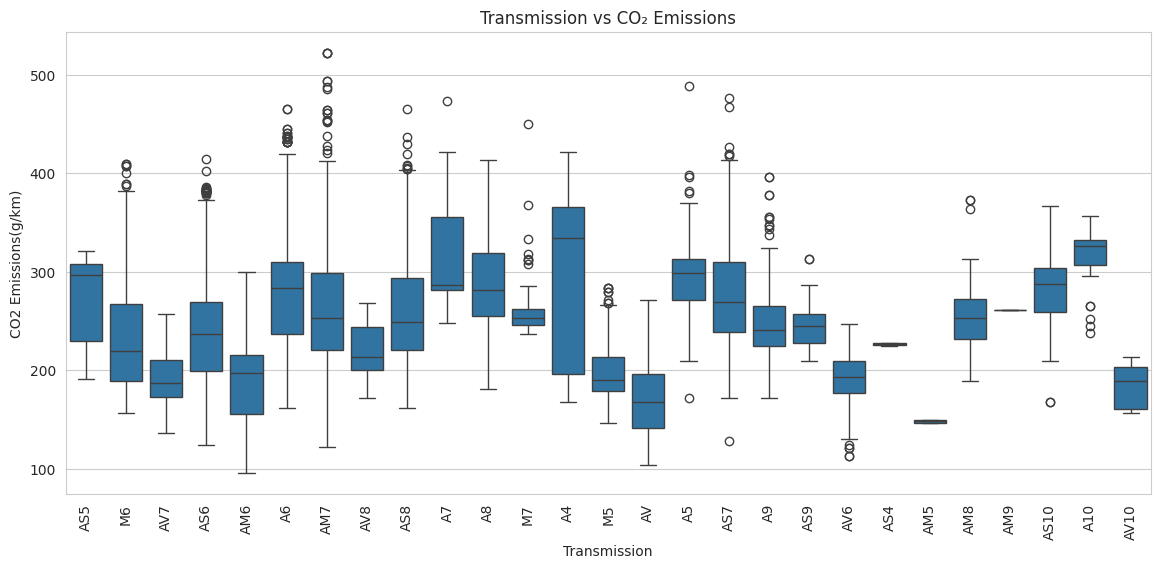

In [26]:
# Transmission vs CO₂
plt.figure(figsize=(14,6))

sns.boxplot(
    data=df,
    x="Transmission",
    y="CO2 Emissions(g/km)"
)

plt.xticks(rotation=90)

plt.title("Transmission vs CO₂ Emissions")

plt.show()

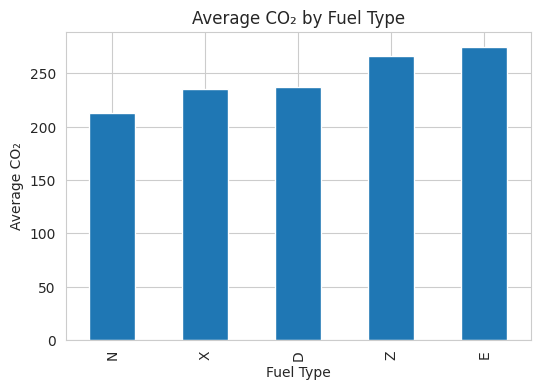

In [27]:
# Average CO₂ by Fuel Type
fuel_avg = (
    df.groupby("Fuel Type")["CO2 Emissions(g/km)"]
      .mean()
      .sort_values()
)

fuel_avg.plot(
    kind="bar",
    figsize=(6,4)
)

plt.ylabel("Average CO₂")

plt.title("Average CO₂ by Fuel Type")

plt.show()

In [28]:
# Summary Table
summary = pd.DataFrame({
    "Correlation with CO₂":
        corr_matrix["CO2 Emissions(g/km)"]
})

summary.sort_values(
    by="Correlation with CO₂",
    ascending=False,
    inplace=True
)

summary

,Correlation with CO₂
CO2 Emissions(g/km),1.000000
Fuel Consumption City (L/100 km),0.919592
Fuel Consumption Comb (L/100 km),0.918052
Fuel Consumption Hwy (L/100 km),0.883536
Engine Size(L),0.851145
Cylinders,0.832644
Fuel Consumption Comb (mpg),-0.907426


The analysis indicates that fuel consumption measures are the strongest predictors of CO₂ emissions, followed by engine size and number of cylinders. Vehicle class and fuel type also influence emissions but to a lesser extent.

The visual analysis demonstrates that fuel consumption metrics are the most influential numerical predictors of CO₂ emissions, followed by engine size and number of cylinders. The strong linear trends observed in the scatter plots and the high correlation coefficients support their use as key predictive features. Additionally, the strong interrelationships among the fuel consumption variables highlight the need to address multicollinearity during model development.

In [29]:
# Q5
# Average CO₂ Emissions by Vehicle Class

vehicle_class_avg = (
    df.groupby("Vehicle Class")["CO2 Emissions(g/km)"]
      .mean()
      .sort_values(ascending=False)
)

print(vehicle_class_avg)

Vehicle Class
VAN - PASSENGER             397.212121
VAN - CARGO                 361.500000
SUV - STANDARD              304.836735
PICKUP TRUCK - STANDARD     301.513011
PICKUP TRUCK - SMALL        278.968553
TWO-SEATER                  277.454348
FULL-SIZE                   263.316119
MINIVAN                     262.312500
SUBCOMPACT                  246.448845
STATION WAGON - MID-SIZE    238.698113
SPECIAL PURPOSE VEHICLE     237.597403
MINICOMPACT                 236.607362
SUV - SMALL                 236.292523
MID-SIZE                    222.455428
COMPACT                     216.679061
STATION WAGON - SMALL       200.067460
Name: CO2 Emissions(g/km), dtype: float64


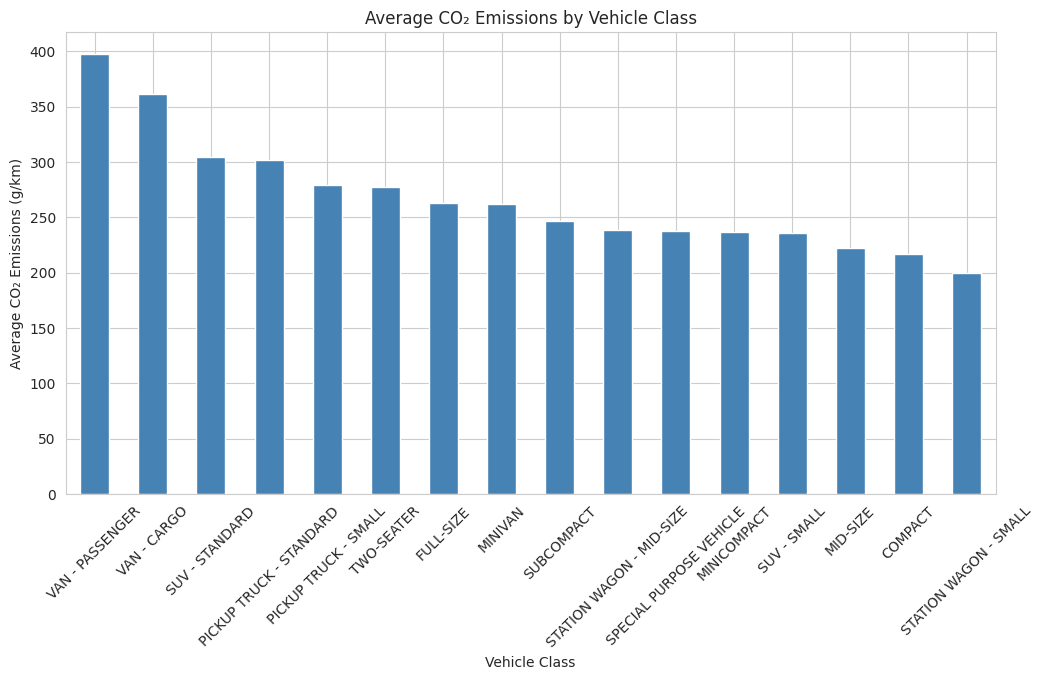

In [30]:
# Bar Chart - Average CO₂ by Vehicle Class
plt.figure(figsize=(12,6))

vehicle_class_avg.plot(
    kind="bar",
    color="steelblue"
)

plt.ylabel("Average CO₂ Emissions (g/km)")
plt.xlabel("Vehicle Class")
plt.title("Average CO₂ Emissions by Vehicle Class")

plt.xticks(rotation=45)

plt.show()

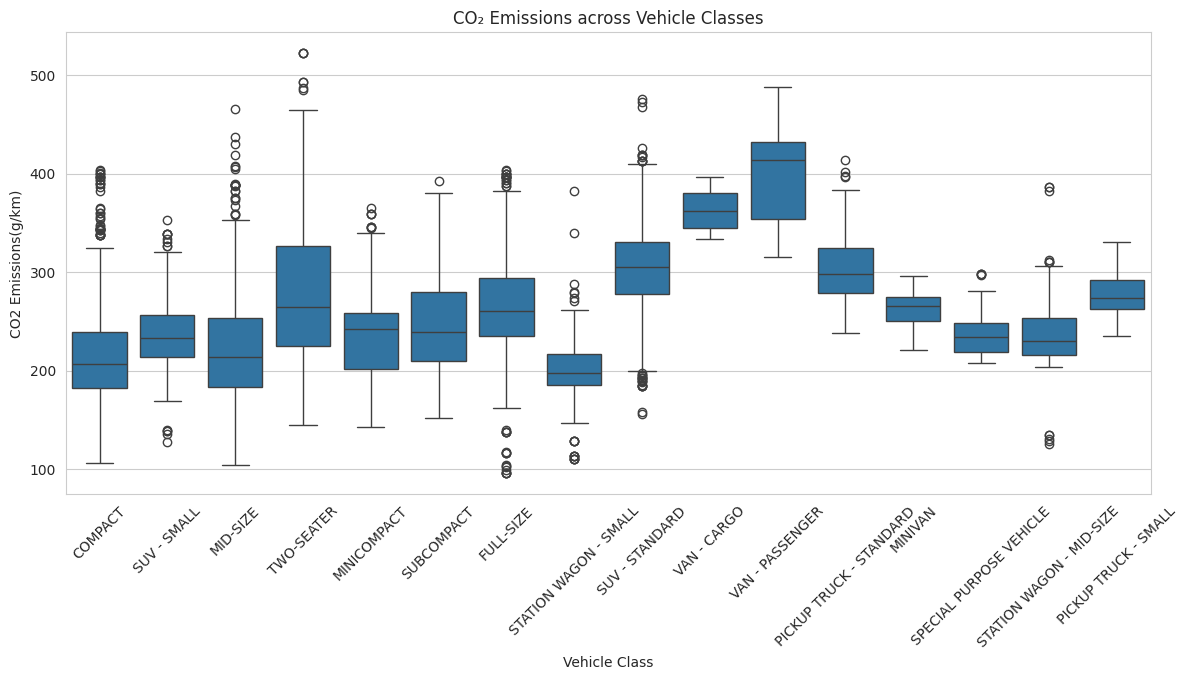

In [31]:
# Boxplot - Vehicle Class vs CO₂
plt.figure(figsize=(14,6))

sns.boxplot(
    data=df,
    x="Vehicle Class",
    y="CO2 Emissions(g/km)"
)

plt.xticks(rotation=45)

plt.title("CO₂ Emissions across Vehicle Classes")

plt.show()

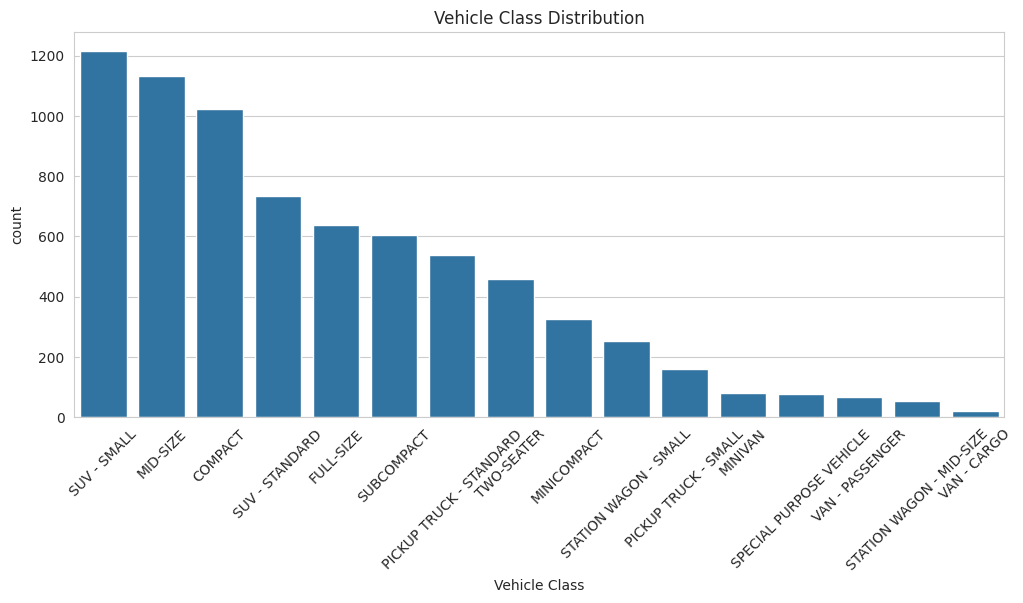

In [32]:
# Count of Vehicles in Each Class
plt.figure(figsize=(12,5))

sns.countplot(
    data=df,
    x="Vehicle Class",
    order=df["Vehicle Class"].value_counts().index
)

plt.xticks(rotation=45)

plt.title("Vehicle Class Distribution")

plt.show()

In [33]:
# Average CO₂ by Fuel Type
fuel_avg = (
    df.groupby("Fuel Type")["CO2 Emissions(g/km)"]
      .mean()
      .sort_values(ascending=False)
)

print(fuel_avg)

Fuel Type
E    275.091892
Z    266.043410
D    237.548571
X    235.119329
N    213.000000
Name: CO2 Emissions(g/km), dtype: float64


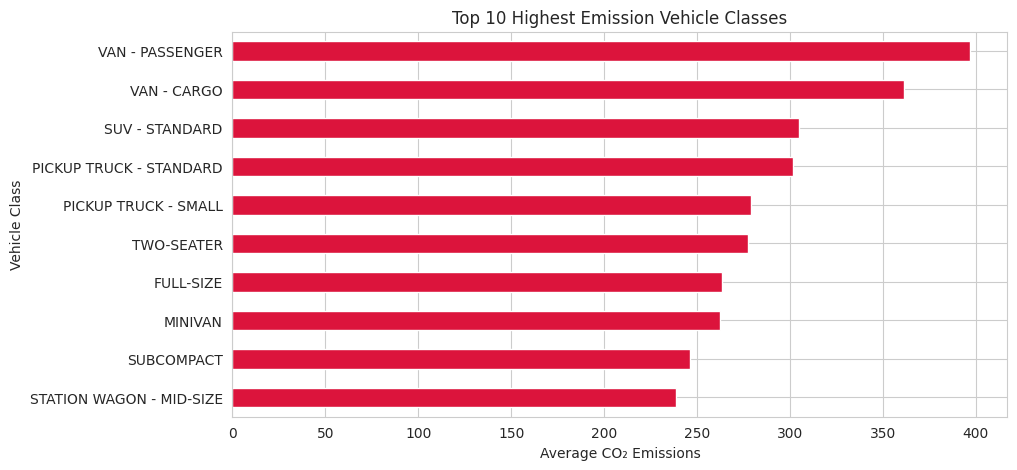

In [34]:
# Top 10 Highest Emission Vehicle Classes
top10 = vehicle_class_avg.head(10)

plt.figure(figsize=(10,5))

top10.plot(
    kind="barh",
    color="crimson"
)

plt.xlabel("Average CO₂ Emissions")

plt.title("Top 10 Highest Emission Vehicle Classes")

plt.gca().invert_yaxis()

plt.show()

The analysis indicates that vehicle class is the strongest categorical factor influencing CO₂ emissions, with larger vehicles consistently producing higher emissions. Fuel type also affects emission levels, but much of its apparent impact is linked to the types of vehicles and engines that use each fuel. These findings suggest that policies promoting smaller, more fuel-efficient vehicle classes and improvements in engine efficiency could have a greater impact on reducing fleet-wide CO₂ emissions than focusing solely on fuel type.

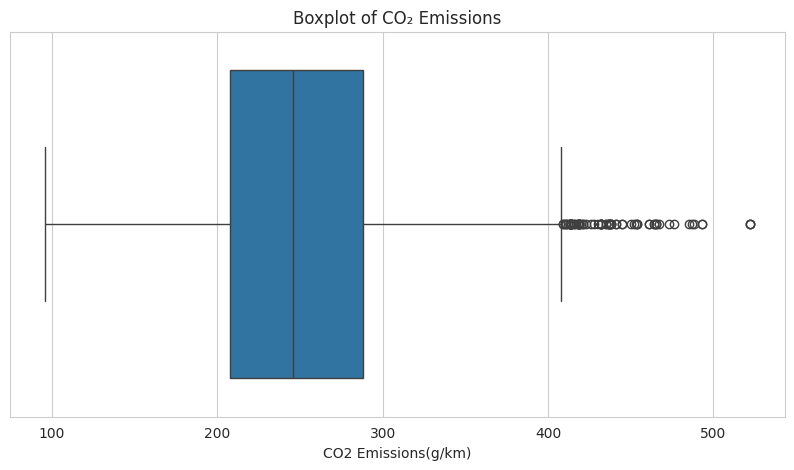

In [37]:
# Detect Outliers Using Boxplot
plt.figure(figsize=(10,5))

sns.boxplot(x=df["CO2 Emissions(g/km)"])

plt.title("Boxplot of CO₂ Emissions")

plt.show()

In [40]:
# Detect Outliers Using IQR
Q1 = df["CO2 Emissions(g/km)"].quantile(0.25)
Q3 = df["CO2 Emissions(g/km)"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Lower Limit :", lower)
print("Upper Limit :", upper)

Lower Limit : 88.0
Upper Limit : 408.0


In [41]:
# View Highest Emission Vehicles

outliers = df[
    (df["CO2 Emissions(g/km)"] < lower) |
    (df["CO2 Emissions(g/km)"] > upper)
]

print("Number of Outliers :", len(outliers))
outliers.sort_values(
    by="CO2 Emissions(g/km)",
    ascending=False
).head(20)

Number of Outliers : 80


,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
5575,BUGATTI,Chiron,TWO-SEATER,8.0,16,AM7,Z,26.8,16.6,22.2,13,522
4509,BUGATTI,CHIRON,TWO-SEATER,8.0,16,AM7,Z,26.8,16.6,22.2,13,522
6640,BUGATTI,Chiron,TWO-SEATER,8.0,16,AM7,Z,26.8,16.6,22.2,13,522
6046,LAMBORGHINI,Aventador Roadster,TWO-SEATER,6.5,12,AM7,Z,26.6,15.8,21.7,13,493
7059,LAMBORGHINI,Aventador Roadster,TWO-SEATER,6.5,12,AM7,Z,26.6,15.8,21.7,13,493
349,FORD,E350 WAGON,VAN - PASSENGER,6.8,10,A5,X,23.9,17.8,21.2,13,488
6045,LAMBORGHINI,Aventador Coupe,TWO-SEATER,6.5,12,AM7,Z,26.3,15.6,21.5,13,487
7058,LAMBORGHINI,Aventador Coupe,TWO-SEATER,6.5,12,AM7,Z,26.2,15.5,21.4,13,485
2971,MERCEDES-BENZ,AMG G 65,SUV - STANDARD,6.0,12,AS7,Z,24.3,17.9,21.4,13,476
5126,MERCEDES-BENZ,AMG G 65,SUV - STANDARD,6.0,12,A7,Z,22.2,18.0,20.3,14,473


In [42]:
# View Highest Emission Vehicles
outliers.sort_values(
    by="CO2 Emissions(g/km)",
    ascending=False
).head(20)

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
5575,BUGATTI,Chiron,TWO-SEATER,8.0,16,AM7,Z,26.8,16.6,22.2,13,522
4509,BUGATTI,CHIRON,TWO-SEATER,8.0,16,AM7,Z,26.8,16.6,22.2,13,522
6640,BUGATTI,Chiron,TWO-SEATER,8.0,16,AM7,Z,26.8,16.6,22.2,13,522
6046,LAMBORGHINI,Aventador Roadster,TWO-SEATER,6.5,12,AM7,Z,26.6,15.8,21.7,13,493
7059,LAMBORGHINI,Aventador Roadster,TWO-SEATER,6.5,12,AM7,Z,26.6,15.8,21.7,13,493
349,FORD,E350 WAGON,VAN - PASSENGER,6.8,10,A5,X,23.9,17.8,21.2,13,488
6045,LAMBORGHINI,Aventador Coupe,TWO-SEATER,6.5,12,AM7,Z,26.3,15.6,21.5,13,487
7058,LAMBORGHINI,Aventador Coupe,TWO-SEATER,6.5,12,AM7,Z,26.2,15.5,21.4,13,485
2971,MERCEDES-BENZ,AMG G 65,SUV - STANDARD,6.0,12,AS7,Z,24.3,17.9,21.4,13,476
5126,MERCEDES-BENZ,AMG G 65,SUV - STANDARD,6.0,12,A7,Z,22.2,18.0,20.3,14,473


In [44]:
# Summary of High-Deviation Vehicles
summary = df.loc[
    outliers.index,
    [
        "Make",
        "Model",
        "Vehicle Class",
        "Engine Size(L)",
        "Cylinders",
        "Fuel Type",
        "Transmission",
        "CO2 Emissions(g/km)"
    ]
]

summary.head(20)

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Fuel Type,Transmission,CO2 Emissions(g/km)
48,AUDI,R8,TWO-SEATER,5.2,10,Z,M6,409
52,AUDI,R8 SPYDER,TWO-SEATER,5.2,10,Z,M6,409
75,BENTLEY,MULSANNE,MID-SIZE,6.8,8,Z,AS8,437
223,CHEVROLET,EXPRESS 2500 PASSENGER,VAN - PASSENGER,4.8,8,X,A6,414
224,CHEVROLET,EXPRESS 2500 PASSENGER,VAN - PASSENGER,6.0,8,X,A6,432
225,CHEVROLET,EXPRESS 2500 PASSENGER,VAN - PASSENGER,6.0,8,E,A6,411
226,CHEVROLET,EXPRESS 3500 PASSENGER,VAN - PASSENGER,4.8,8,X,A6,419
227,CHEVROLET,EXPRESS 3500 PASSENGER,VAN - PASSENGER,6.0,8,X,A6,435
228,CHEVROLET,EXPRESS 3500 PASSENGER,VAN - PASSENGER,6.0,8,E,A6,413
349,FORD,E350 WAGON,VAN - PASSENGER,6.8,10,X,A5,488


The analysis shows that most emission outliers are genuine high-performance or heavy-duty vehicles rather than data quality issues. Comparing similar vehicles reveals that engine size alone does not fully explain CO₂ emissions—vehicle class, fuel consumption, transmission, and manufacturer-specific engineering also contribute to deviations. Residual analysis further identifies cases where the model under- or over-predicts emissions, suggesting that additional vehicle characteristics could improve predictive accuracy.